# Section 1: Business Understanding

This notebook aims to identify and address key business questions using datasets from the Centers for Medicare & Medicaid Services (CMS). The datasets primarily focus on medical facilities that accept Medicare and Medicaid patients. This analysis follows the CRISP-DM (Cross-Industry Standard Process for Data Mining) framework.

The datasets used in this project are:
- `Hospital_General_Information.csv`
- `HCAHPS-Hospital.csv`
- `FY_2025_Hospital_Readmissions_Reduction_Program_Hospital.csv`

The datasets can be found [here](https://data.cms.gov/provider-data/datasets).

Three business questions guide the analysis:  

**Question 1. Where do Medicare-serving hospitals appear to have structural or service-access gaps?**  

**Question 2. How do patient experience measures vary across hospitals, and what do they tell us about hospital quality?**  

**Question 3. Can hospital characteristics and patient experience indicators help identify hospitals at risk of above-expected heart failure readmissions?**

In [ ]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

# Section 2: Data Understanding

## Data loading, cleaning, and preprocessing

### Load data

In [2]:
# load the datasets
hgi = pd.read_csv('./data/Hospital_General_Information.csv')
hcahps = pd.read_csv('./data/HCAHPS-Hospital.csv')
hrrp = pd.read_csv('./data/FY_2025_Hospital_Readmissions_Reduction_Program_Hospital.csv')

C:\Users\jnam\AppData\Local\Temp\ipykernel_3604\1307960456.py:3: DtypeWarning: Columns (12,14,17,19) have mixed types. Specify dtype option on import or set low_memory=False.
  hcahps = pd.read_csv('./data/HCAHPS-Hospital.csv')


### Assess data

In [3]:
hgi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5421 entries, 0 to 5420
Data columns (total 38 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   Facility ID                                       5421 non-null   object 
 1   Facility Name                                     5421 non-null   object 
 2   Address                                           5421 non-null   object 
 3   City/Town                                         5421 non-null   object 
 4   State                                             5421 non-null   object 
 5   ZIP Code                                          5421 non-null   int64  
 6   County/Parish                                     5421 non-null   object 
 7   Telephone Number                                  5421 non-null   object 
 8   Hospital Type                                     5421 non-null   object 
 9   Hospital Ownership 

In [4]:
hcahps.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 445563 entries, 0 to 445562
Data columns (total 22 columns):
 #   Column                                 Non-Null Count   Dtype 
---  ------                                 --------------   ----- 
 0   Facility ID                            445563 non-null  object
 1   Facility Name                          445563 non-null  object
 2   Address                                445563 non-null  object
 3   City/Town                              445563 non-null  object
 4   State                                  445563 non-null  object
 5   ZIP Code                               445563 non-null  int64 
 6   County/Parish                          445563 non-null  object
 7   Telephone Number                       445563 non-null  object
 8   HCAHPS Measure ID                      445563 non-null  object
 9   HCAHPS Question                        445563 non-null  object
 10  HCAHPS Answer Description              445563 non-null  object
 11  

In [5]:
hrrp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18510 entries, 0 to 18509
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Facility Name               18510 non-null  object 
 1   Facility ID                 18510 non-null  int64  
 2   State                       18510 non-null  object 
 3   Measure Name                18510 non-null  object 
 4   Number of Discharges        8340 non-null   float64
 5   Footnote                    6583 non-null   float64
 6   Excess Readmission Ratio    11927 non-null  float64
 7   Predicted Readmission Rate  11927 non-null  float64
 8   Expected Readmission Rate   11927 non-null  float64
 9   Number of Readmissions      11927 non-null  object 
 10  Start Date                  18510 non-null  object 
 11  End Date                    18510 non-null  object 
dtypes: float64(5), int64(1), object(6)
memory usage: 1.7+ MB


**Initial inspection using .info() reveals varying dataset sizes, predominantly object-type variables, and substantial missingness in specific measure-related columns.**

### Clean data

In [6]:
# filter the datasets by selecting the columns needed
# hgi
hgi_select_cols = ['Facility ID','Facility Name','State','County/Parish','Hospital Type','Hospital Ownership','Emergency Services','Hospital overall rating']
hgi_filtered = hgi[hgi_select_cols].copy()

# keep only hospital identity, location, structural characteristics, emergency service availability, and overall quality variables
# because these fields directly support the business questions on service-access gaps and hospital quality differences.

# hcahps
hcahps_select_cols = ['Facility ID','Facility Name','Patient Survey Star Rating','HCAHPS Linear Mean Value','HCAHPS Answer Percent','Number of Completed Surveys'] # HCAHPS linear mean scores are used in the construction of HCAHPS star ratings. The linear mean scores employ all survey response categories for the items in each HCAHPS measure and are converted and combined into a 0-100 linear-scaled measure score.
hcahps_filtered = hcahps[hcahps_select_cols].copy()


# keep only hospital identifiers and summary HCAHPS variables that capture patient experience level, response distribution, and survey volume
# because these are the most relevant fields for comparing hospital experience and using patient experience as a predictor in modeling.


# hrrp
hrrp_select_cols = ['Facility ID','Facility Name','Measure Name','Excess Readmission Ratio'] # In October 2012, CMS began reducing Medicare payments for subsection(d) hospitals with excess readmissions. Excess readmissions are measured by a ratio, calculated by dividing a hospital's predicted rate of readmission for heart attack (AMI), heart failure (HF), pneumonia, chronic obstructive pulmonary disease (COPD), hip/knee replacement (THA/TKA), and coronary artery bypass graft (CABG) surgery by the expected rate of readmission, based on an average hospital with similar patients.
hrrp_filtered = hrrp[hrrp_select_cols].copy()


# keep only the hospital identifier, HRRP condition name, and Excess Readmission Ratio
# because the project focuses on condition-specific readmission risk, especially heart failure readmission performance


In [7]:
# transform 'Not Available' to null values, then change the data type
hgi_filtered['Hospital overall rating'] = hgi_filtered['Hospital overall rating'].replace({'Not Available':np.nan}).astype(float)

## Exploratory data analysis

### State/county hospital distribution
<a id="q1-state-distribution"></a>

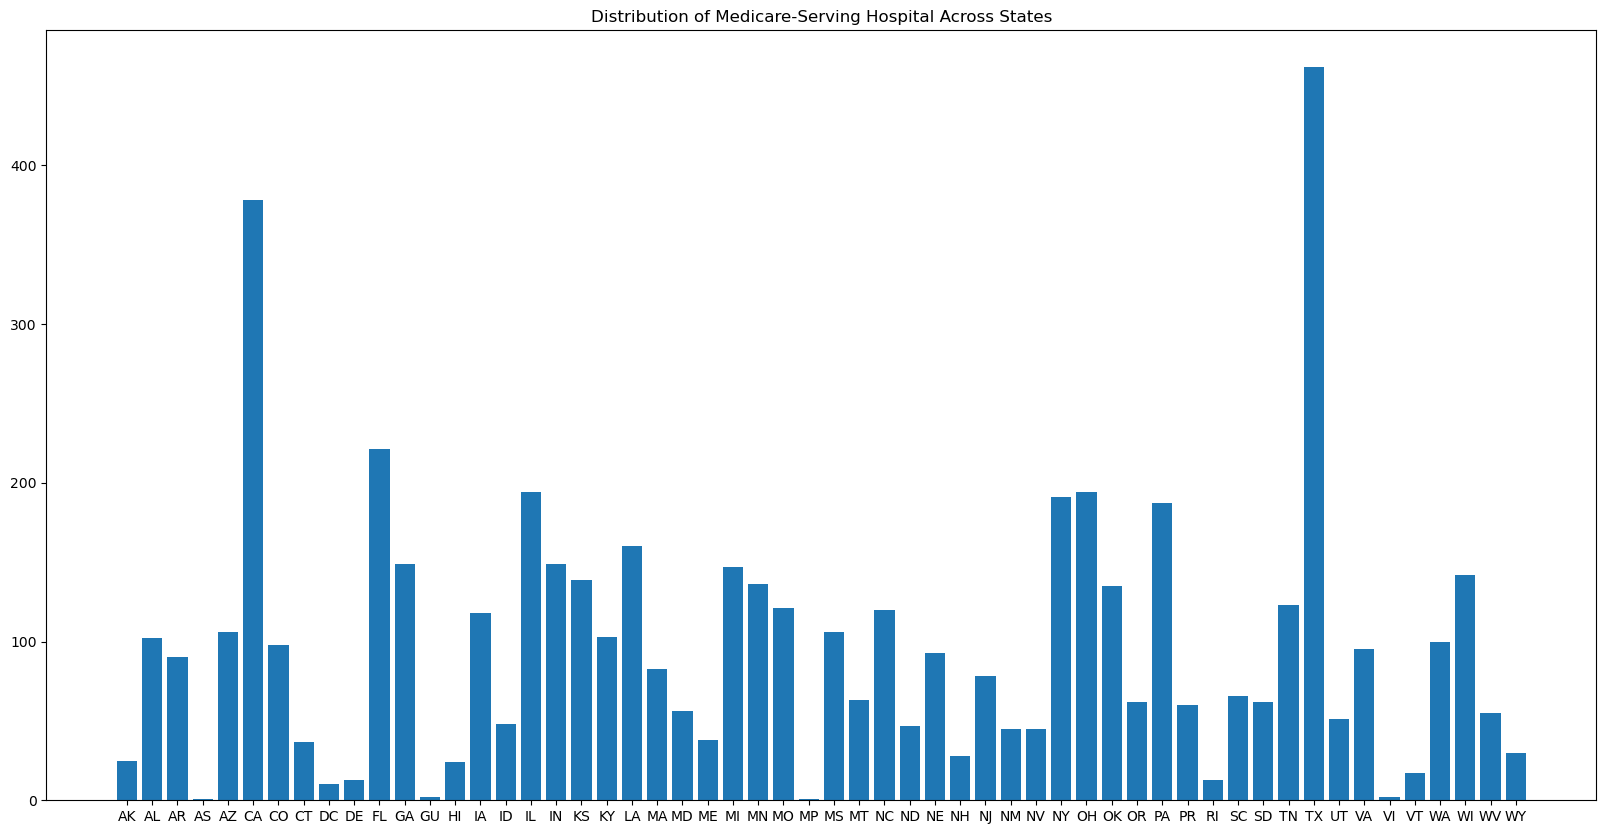

In [8]:
# draw a bar plot
plt.figure(figsize=(20,10))
plt.bar(data=hgi_filtered.groupby('State')['Facility ID'].nunique().reset_index(), x='State', height='Facility ID')
plt.title('Distribution of Medicare-Serving Hospital Across States');

**The absolute number of hospitals is low in many states including AS, GU, MP, RI, and VI.**

### Hospital overall rating based on hospital type, ownership, and emergency services

In [9]:
def plot_mean_by_category(df, category_col, target_col):
    """
    Group by a categorical column, compute mean of target column, and draw a bar plot
    """
    # drop categories whose mean target value is undefined so the summary plot; only displays interpretable category-level averages
    summary = df.groupby(category_col)[target_col].mean().dropna().sort_values(ascending=False)


    plt.figure(figsize=(10,5))
    ax = summary.plot(kind='bar')
    plt.xlabel(category_col)
    plt.ylabel(f'Mean {target_col}')
    plt.title(f'Mean {target_col} by {category_col}')
    plt.show()
    

<a id="q1-rating-by-type"></a>

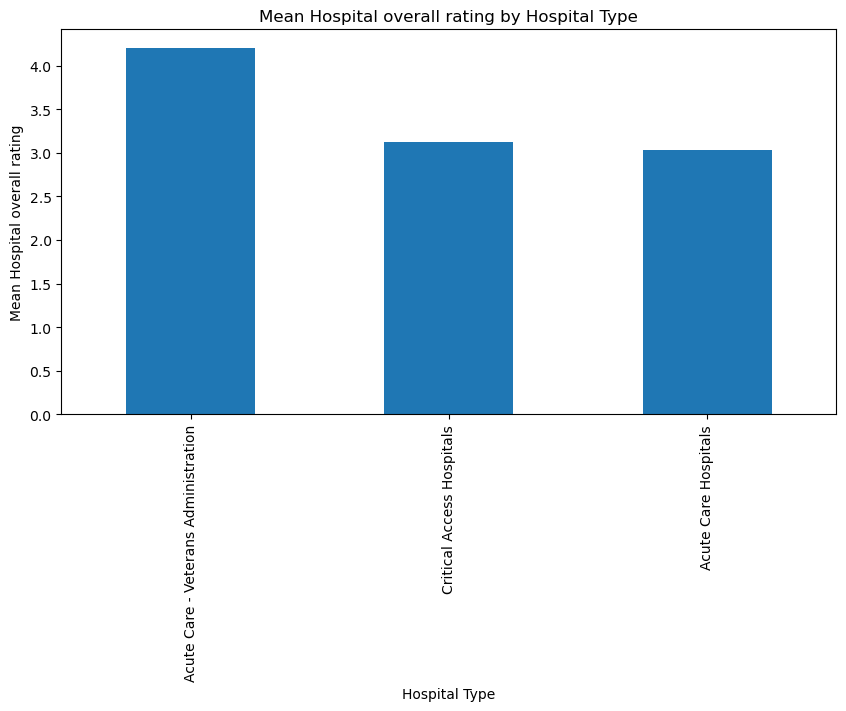

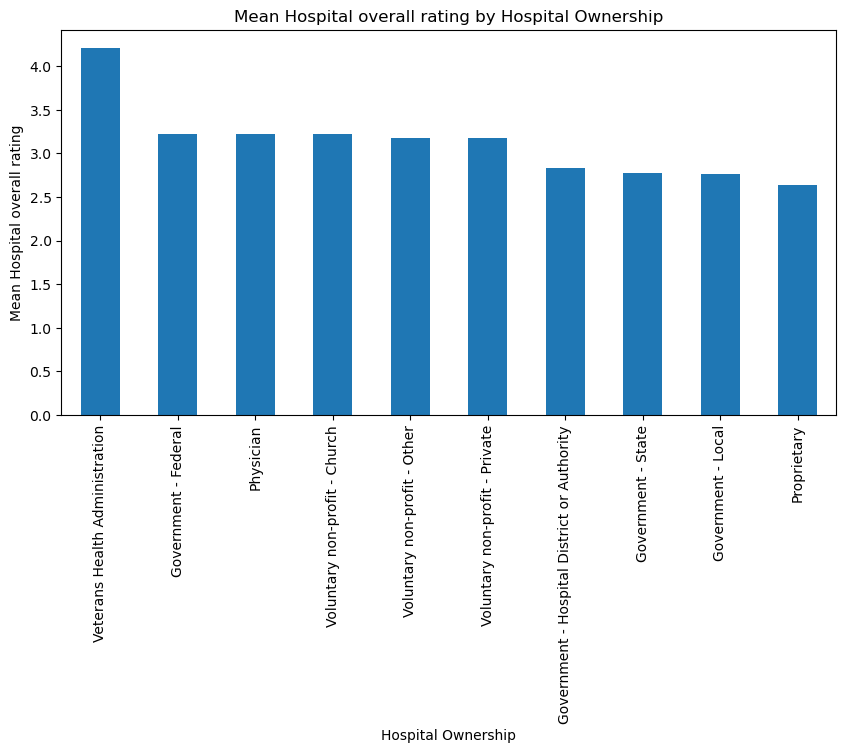

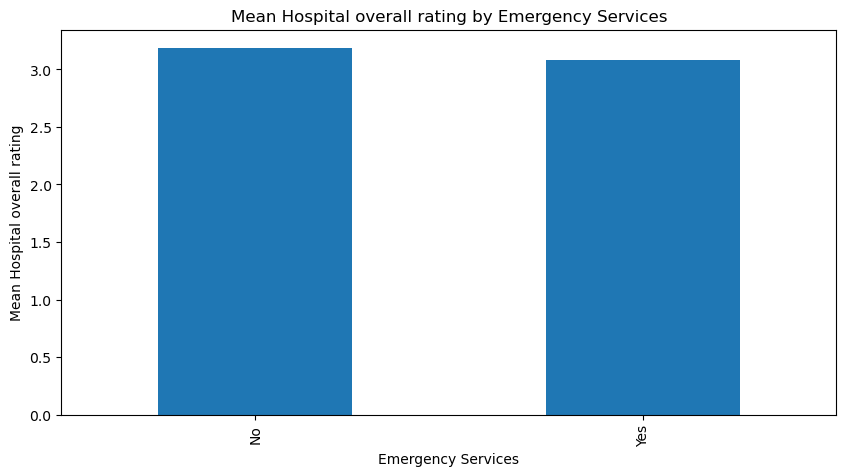

In [10]:
# group by hospital type, ownership, and emergency services and draw a bar plot for the mean values for each category
groupby_columns = [
    'Hospital Type',
    'Hospital Ownership',
    'Emergency Services'
]

for col in groupby_columns:
    plot_mean_by_category(
        df=hgi_filtered,
        category_col=col,
        target_col='Hospital overall rating'
    )

**Veterans Administration owned/operated hospitals have higher overall ratings in mean than other owned/types of hospitals**

### HCAHPS linear mean value/star rating distribution

In [11]:
def plot_histogram(df, col_name, bins=20):
    """
    Plot a histogram for a given dataframe column after dropping out specified text values such as Not Applicable and Not Available
    """
    # filter N/A values    
    # remove text placeholders and non-numeric entries so the histogram reflects only valid numeric survey scores rather than missing-value labels

    text_to_drop = ['Not Applicable', 'Not Available']
    filtered = df.loc[~df[col_name].isin(text_to_drop), col_name]
    filtered = pd.to_numeric(filtered, errors="coerce")
    filtered = filtered.dropna()

    # Plot histogram
    plt.figure(figsize=(6, 4))
    plt.hist(filtered, bins=bins)
    plt.xlabel(col_name)
    plt.ylabel("Frequency")
    plt.title(f"Distribution of {col_name}")
    plt.tight_layout()
    plt.show()

<a id="q2-hcahps-distribution"></a>

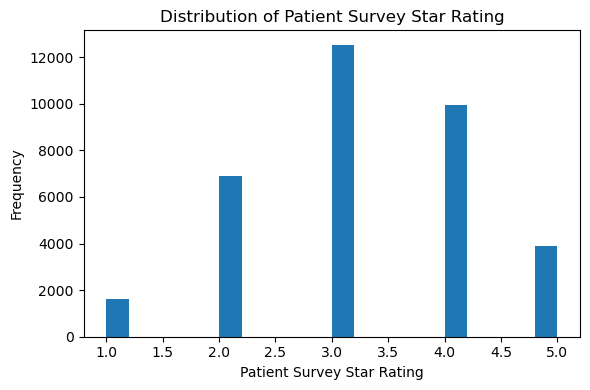

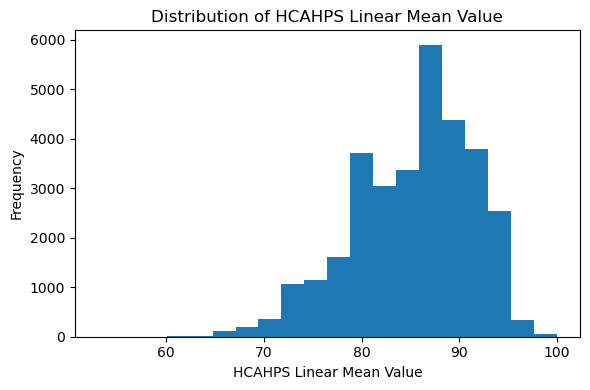

In [12]:
# histogram for Patient Survey Star Rating
plot_histogram(
    df=hcahps_filtered,
    col_name='Patient Survey Star Rating',
    bins=20
)

# histogram for HCAHPS Linear Mean Value
plot_histogram(
    df=hcahps_filtered,
    col_name='HCAHPS Linear Mean Value',
    bins=20
)

**Star ratings are concentrated at 3-4 stars with the highest frequency at 3, while HCAHPS linear mean scores are continuously distributed, mostly ranging from approximately 80 to 95.**

### Relationship between the number of completed surveys and rating (skewness of low-sample hospitals)

In [13]:
from typing import Literal

def draw_plot(df, col_name_x, col_name_y, type: Literal["box", "scatter"]):
    """
    Draw a selected type of plot for a given dataframe column after dropping out specified text values such as Not Applicable and Not Available
    """
    # filter N/A values
    text_to_drop = ['Not Applicable', 'Not Available']
    filtered = df[~(df[col_name_x].isin(text_to_drop)) & ~(df[col_name_y].isin(text_to_drop))][[col_name_x, col_name_y]]
    filtered = filtered.astype(float)
    filtered = filtered.dropna()

    if type == "box":
        sns.boxplot(data=filtered,
                    x=col_name_x,
                    y=col_name_y,
                    showfliers=False
                    )
        
    if type == "scatter":
        sns.scatterplot(data=filtered,
                    x=col_name_x,
                    y=col_name_y,
                    )
    plt.xlabel(col_name_x)
    plt.ylabel(col_name_y)
    plt.title(f"Distribution of {col_name_y} by {col_name_x}")
    plt.tight_layout()
    plt.show()

<a id="q2-survey-volume"></a>

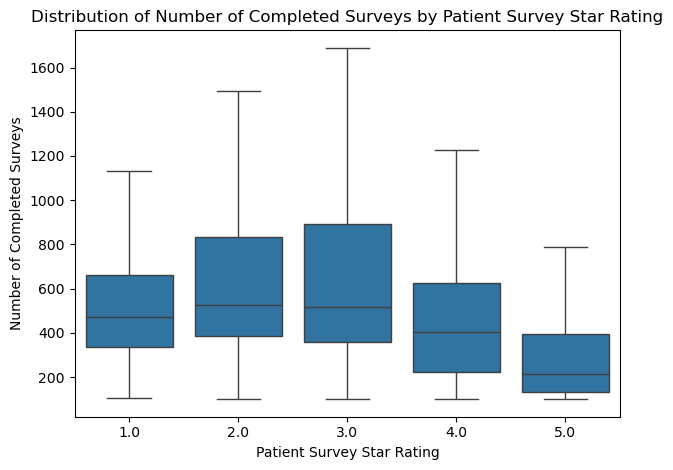

In [14]:
draw_plot(hcahps_filtered, 'Patient Survey Star Rating', 'Number of Completed Surveys', type='box');

**Completed survey counts are highest and most variable for 2-3 star ratings, while higher ratings, particularly 5 stars, are associated with lower and tighter distributions.**

### Correlation of hcahps rating with hospital overall rating in general info dataset

In [15]:
# merge two dataframes, then clean it
hospital_ratings = pd.merge(hcahps_filtered, hgi_filtered, on=['Facility ID','Facility Name'])[['Facility Name','HCAHPS Linear Mean Value', 'Hospital overall rating']].reset_index()
hospital_ratings = hospital_ratings.dropna()  # for the relationship between HCAHPS score and overall hospital rating, keep only hospitals with both measures available
hospital_ratings = hospital_ratings[~(hospital_ratings['HCAHPS Linear Mean Value'] == "Not Applicable") & ~(hospital_ratings['HCAHPS Linear Mean Value'] == "Not Available")].reset_index()

<a id="q2-hcahps-overall-rating"></a>

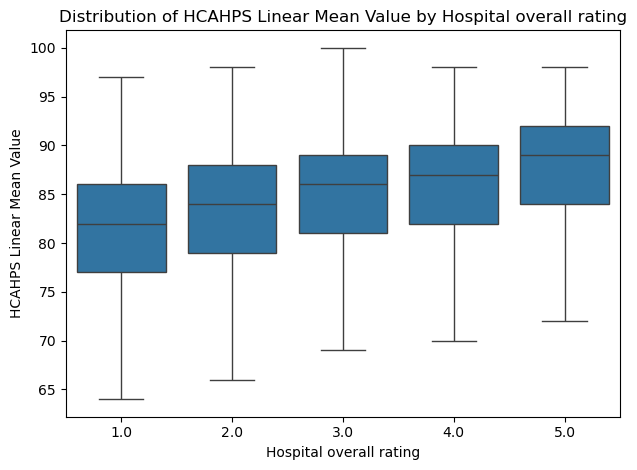

In [16]:
# draw a box plot for HCAHPS Linear Mean Value per Hospital overall rating
draw_plot(hospital_ratings, 'Hospital overall rating', 'HCAHPS Linear Mean Value', type='box');

**HCAHPS Linear Mean Values increase monotonically with Hospital Overall Rating, indicating that hospitals with higher overall ratings consistently achieve higher patient experience scores.**

### Readmission ratio distribution per disease (measure name)

In [17]:
# distribution of reported Excess Readmission Ratio per disease
hrrp_filtered.dropna(subset='Excess Readmission Ratio').groupby('Measure Name')['Excess Readmission Ratio'].count().sort_values(ascending=False)

Measure Name
READM-30-PN-HRRP          2731
READM-30-HF-HRRP          2638
READM-30-COPD-HRRP        2324
READM-30-AMI-HRRP         1763
READM-30-HIP-KNEE-HRRP    1588
READM-30-CABG-HRRP         883
Name: Excess Readmission Ratio, dtype: int64

**PN (pneumonia) and HF (heart failure) have the highest reported Excess Readmission Ratio.**

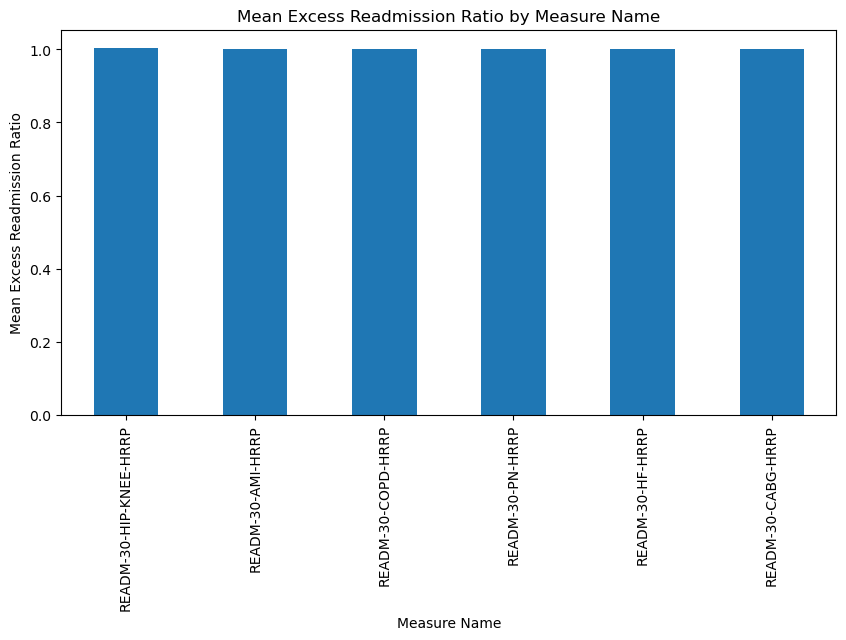

In [18]:
# plot the mean of readmission ratio by disease
plot_mean_by_category(hrrp_filtered, 'Measure Name', 'Excess Readmission Ratio');

**Across all HRRP conditions - AMI (heart attack), HF (heart failure), PN (pneumonia), COPD, CABG surgery, and hip/knee replacement - the mean Excess Readmission Ratio remains close to 1.0, indicating that average hospital readmission performance is broadly aligned with the national benchmark regardless of disease category.**

### Differences in risk based on region, ownership, and type of hospital

In [19]:
# merge hrrp with hgi
# drop rows with missing readmission or hospital-attribute values because category-level comparisons by state, type, and ownership require complete records
hrrp_hgi_filtered = pd.merge(hrrp_filtered, hgi_filtered[['Facility Name', 'State', 'Hospital Type', 'Hospital Ownership']], on='Facility Name', how='left').dropna().reset_index(drop=True)

In [20]:
def plot_median_by_category(df, category_col, target_col, height_per_row=0.15, min_height=4):
    """
    Plot median of target column by category as a dot plot with reference line
    """
    summary = (
        df.groupby(category_col)[target_col]
        .median()
        .dropna()
        .sort_values()
    )

    n = len(summary)
    fig_height = max(min_height, n * height_per_row)

    plt.figure(figsize=(8, fig_height))
    plt.scatter(summary.values, summary.index)
    plt.axvline(1.0, color='red', linestyle='--', linewidth=1)
    plt.xlim([0.95, 1.05])

    plt.xlabel(f'Mean {target_col}')
    plt.ylabel(category_col)
    plt.title(f'Mean {target_col} by {category_col}')
    plt.tight_layout()
    plt.show()


<a id="q3-readmission-by-category"></a>

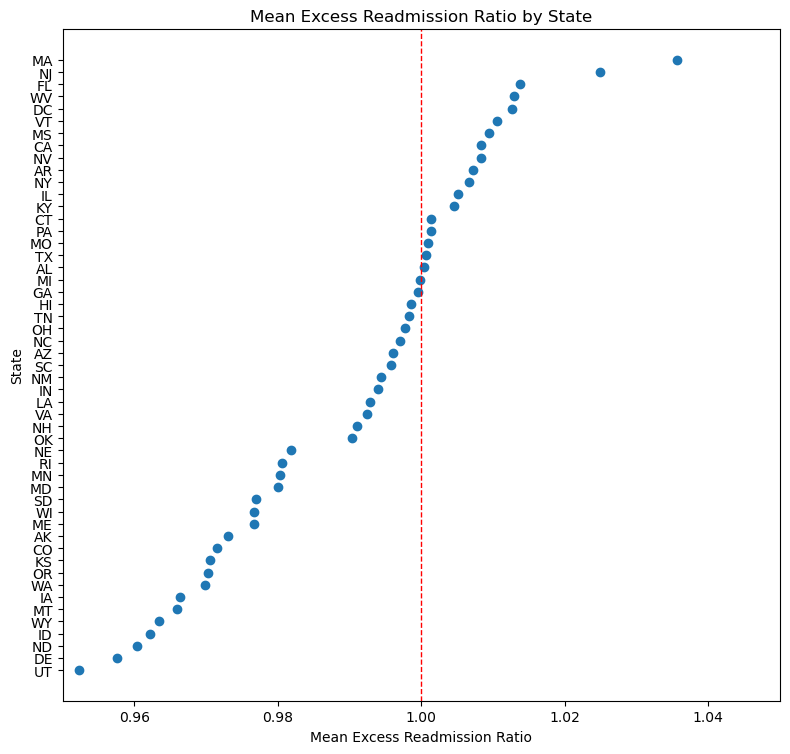

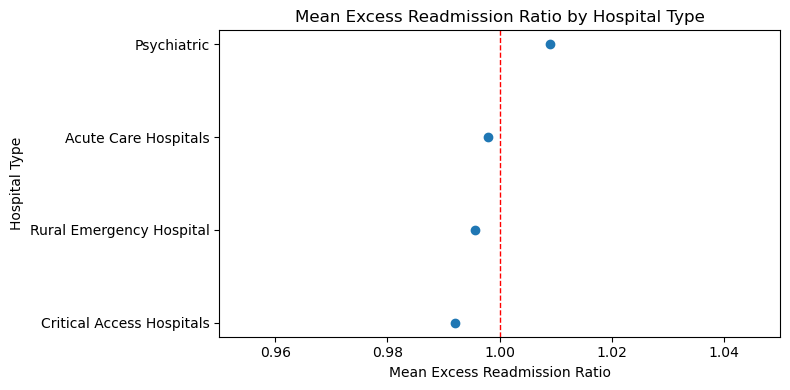

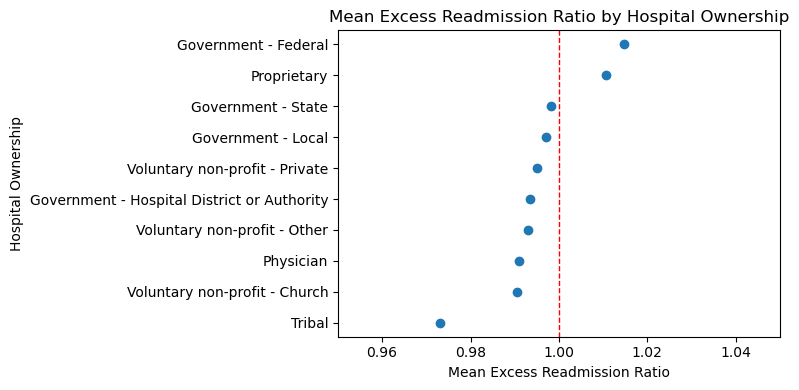

In [21]:
# visualize the risk based on three factors
category_cols = ['State', 'Hospital Type', 'Hospital Ownership']
for col in category_cols:
    plot_median_by_category(hrrp_hgi_filtered, col, 'Excess Readmission Ratio');

**Across states, hospital types, and ownership categories, mean Excess Readmission Ratios cluster tightly around the CMS benchmark of 1.0, with modest but systematic deviations suggesting that readmission performance varies more subtly by institutional and geographic characteristics than by large structural differences.**

### Relationship between hcahps and hrrp; hospital w/ good experience - hospital service outcome quality

In [22]:
# take the mean Excess Readmission Ratio by facility
hrrp_by_facility = hrrp_filtered.groupby('Facility Name')['Excess Readmission Ratio'].mean().reset_index()

In [23]:
# take the mean HCAHPS Linear Mean Value by facility
# filter N/A values
text_to_drop = ['Not Applicable', 'Not Available']
hcahps_by_facility = hcahps_filtered[~hcahps_filtered['HCAHPS Linear Mean Value'].isin(text_to_drop)].reset_index(drop=True)
hcahps_by_facility['HCAHPS Linear Mean Value'] = hcahps_by_facility['HCAHPS Linear Mean Value'].astype(float)
hcahps_by_facility = hcahps_by_facility.groupby('Facility Name')['HCAHPS Linear Mean Value'].mean().reset_index()

In [24]:
# merge hcahps_by_facility with hrrp_by_facility
hcahps_hrrp_by_facility = pd.merge(hcahps_by_facility, hrrp_by_facility, on='Facility Name', how='inner').reset_index(drop=True)

<a id="q3-hcahps-readmission-scatter"></a>

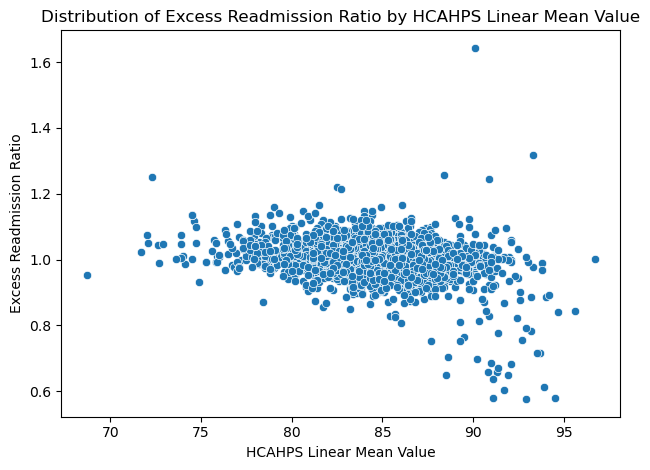

In [25]:
draw_plot(hcahps_hrrp_by_facility, 'HCAHPS Linear Mean Value', 'Excess Readmission Ratio', type='scatter');

**Higher HCAHPS Linear Mean Values are generally associated with slightly lower Excess Readmission Ratios, though the relationship is weak and highly variable.**

# Section 3: Data Preparation

## Prepare X and y

In [26]:
# prepare a modeling-ready dataframe by merging previous dataframes
feature_cols = ['Hospital Type','Hospital Ownership','Emergency Services','State','HCAHPS Linear Mean Value']
raw_target_col = ['Excess Readmission Ratio']
combined_df = pd.merge(hgi_filtered[['Facility Name'] + [col for col in feature_cols if col in hgi_filtered.columns]], hcahps_by_facility, on='Facility Name', how='inner').reset_index(drop=True)
combined_df = pd.merge(combined_df, hrrp_filtered.drop(columns='Facility ID'), on='Facility Name', how='inner').reset_index(drop=True)
combined_df = combined_df.dropna()
assert set(feature_cols).issubset(combined_df.columns)
assert set(raw_target_col).issubset(combined_df.columns)

In [27]:
# filter Heart Failure (HF)
# restrict the target to heart failure so the prediction task stays clinically consistent and easy to interpret, rather than mixing different readmission measures
hf = combined_df[combined_df['Measure Name'] == "READM-30-HF-HRRP"].reset_index(drop=True)

# groupby the facility name and take the mean Excess Readmission Ratio
hf = hf.groupby([col for col in hf.columns if col not in ["Excess Readmission Ratio"]])['Excess Readmission Ratio'].mean().reset_index()

# add a new column for binary target: 1 if ERR > 1, else 0
hf['hf_err_gt_1'] = (hf['Excess Readmission Ratio'] > 1).astype(int)

In [28]:
# check the distribution of hf_err_gt_1
hf['hf_err_gt_1'].value_counts()

hf_err_gt_1
1    1242
0    1240
Name: count, dtype: int64

In [29]:
# keep only columns needed for the model
df_model = hf[feature_cols + ['hf_err_gt_1']].copy()
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2482 entries, 0 to 2481
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Hospital Type             2482 non-null   object 
 1   Hospital Ownership        2482 non-null   object 
 2   Emergency Services        2482 non-null   object 
 3   State                     2482 non-null   object 
 4   HCAHPS Linear Mean Value  2482 non-null   float64
 5   hf_err_gt_1               2482 non-null   int64  
dtypes: float64(1), int64(1), object(4)
memory usage: 116.5+ KB


In [30]:
# one-hot encoding for categorical variables
categorical_cols = ["Hospital Type", "Hospital Ownership", "Emergency Services", "State"]
df_model_encoded = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)

# Take X and y
X = df_model_encoded.drop(columns=['hf_err_gt_1'])
y = df_model_encoded['hf_err_gt_1']

# Section 4: Data Modeling

To answer the question X, the classification model of yy should be useful. Based on the results from the exploratory data analysis, ~~

Input variables: Hospital Type, Ownership, Emergency Services, State, HCAHPS Linear Mean Value  
Target variable: Excess Readmission Ratio > 1 on Heart Failure (HF) (True or False for binary classification)

## Train a model

In [31]:
from sklearn.model_selection import train_test_split

# train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [32]:
from sklearn.linear_model import LogisticRegression

# train a logistic regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


## Evaluate the model

In [33]:
# predict the test set
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

In [34]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# print the metrics of the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
cm = confusion_matrix(y_test, y_pred)

print("Model Evaluation")
print("-" * 40)
print("Accuracy :", round(accuracy, 2))
print("Precision:", round(precision, 2))
print("Recall   :", round(recall, 2))
print("F1-score :", round(f1, 2))
print("Confusion Matrix:")
print(cm)

Model Evaluation
----------------------------------------
Accuracy : 0.61
Precision: 0.61
Recall   : 0.62
F1-score : 0.62
Confusion Matrix:
[[151  97]
 [ 95 154]]


In [35]:
# inspect logistic regression coefficients for a simple interpretation of directional effects.
coef_df = pd.DataFrame(
    {
        "feature": X.columns,
        "coefficient": model.coef_[0],
        "abs_coefficient": np.abs(model.coef_[0]),
    }
).sort_values("abs_coefficient", ascending=False)

coef_df.head(10)

,feature,coefficient,abs_coefficient
32,State_MA,1.248267,1.248267
60,State_WA,-1.243064,1.243064
34,State_ME,-1.072906,1.072906
59,State_VT,1.062331,1.062331
10,Hospital Ownership_Voluntary non-profit - Church,-1.029982,1.029982
18,State_CO,-0.939779,0.939779
29,State_KS,-0.913030,0.913030
36,State_MN,-0.907645,0.907645
57,State_UT,-0.871778,0.871778
63,State_WY,-0.864692,0.864692


# Section 5: Evaluate the Results

## **Question 1. Where do Medicare-serving hospitals appear to have structural or service-access gaps?**

**Relevant visuals:**
- [Hospital distribution across states](#q1-state-distribution)
- [Mean overall rating by hospital type, ownership, emergency services](#q1-rating-by-type)

The clearest geographic gap is that some areas—especially **AS, GU, MP, RI, and VI**—have relatively few Medicare-serving hospitals, which suggests more limited hospital availability there. Across hospital segments, **Veterans Administration owned or operated hospitals have higher mean overall ratings than other ownership groups**, and mean overall rating also differs by **hospital type** and **emergency-service status**. Together, these results suggest that structural gaps appear both in **where hospitals are concentrated** and in **how hospital quality differs across ownership and service configurations**.

## **Question 2. How do patient experience measures vary across hospitals, and what do they tell us about hospital quality?**

**Relevant visuals:**
- [Distribution of HCAHPS star rating and linear mean value](#q2-hcahps-distribution)
- [Completed surveys by patient survey star rating](#q2-survey-volume)
- [HCAHPS Linear Mean Value vs overall hospital rating](#q2-hcahps-overall-rating)

HCAHPS scores show meaningful variation across hospitals.
Patient survey star ratings tend to cluster around the middle categories, while HCAHPS linear mean values are spread across a narrower but continuous range.
Higher HCAHPS linear mean values are generally associated with higher overall hospital ratings, which suggests that patient experience is aligned with broader hospital quality signals.
Survey volume also varies by rating level, indicating that some hospital groups have more stable patient-experience estimates than others.

## **Question 3. Can hospital characteristics and patient experience indicators help identify hospitals at risk of above-expected heart failure readmissions?**

**Relevant visuals:**
- [Excess Readmission Ratio by state, hospital type, and ownership](#q3-readmission-by-category)
- [HCAHPS Linear Mean Value vs Excess Readmission Ratio](#q3-hcahps-readmission-scatter)

Model evaluation using the confusion matrix,

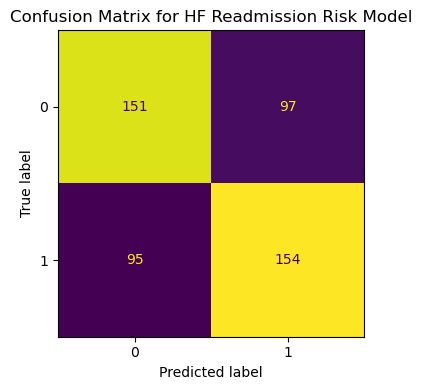

In [36]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix=cm).plot(ax=ax, colorbar=False)
plt.title("Confusion Matrix for HF Readmission Risk Model")
plt.tight_layout()
plt.show()

Top logistic regression coefficients,

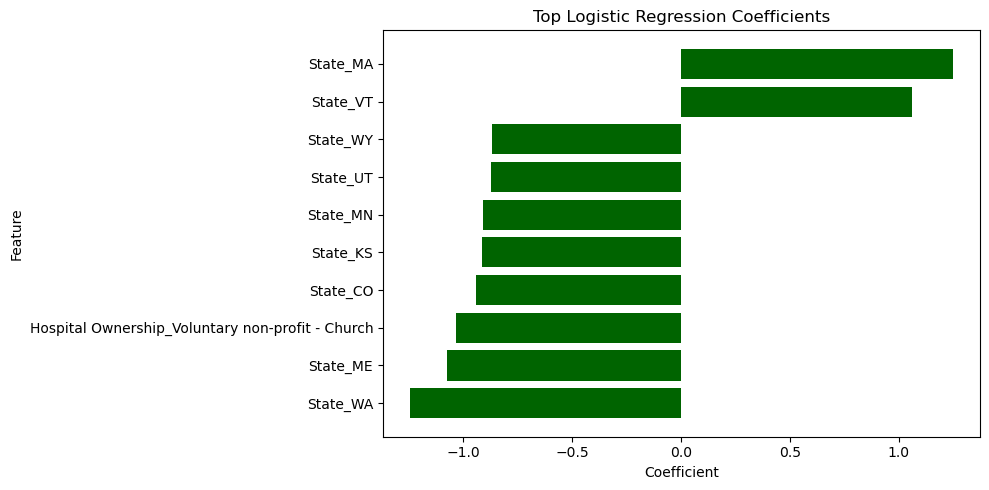

In [37]:
top_coef = coef_df.head(10).copy().sort_values("coefficient")
plt.figure(figsize=(10, 5))
plt.barh(top_coef["feature"], top_coef["coefficient"], color="darkgreen")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Top Logistic Regression Coefficients")
plt.tight_layout()
plt.show()

In [40]:
# build a simple hypothetical prediction scenario.
example = pd.DataFrame(
    [
        {
            "Hospital Type": df_model["Hospital Type"].mode()[0],
            "Hospital Ownership": df_model["Hospital Ownership"].mode()[0],
            "Emergency Services": "Yes",
            "State": df_model["State"].mode()[0],
            "HCAHPS Linear Mean Value": 82,
        }
    ]
)

example_encoded = pd.get_dummies(example, columns=categorical_cols, drop_first=True)
example_encoded = example_encoded.reindex(columns=X.columns, fill_value=0)

example_pred_class = model.predict(example_encoded)[0]
example_pred_prob = model.predict_proba(example_encoded)[0, 1]


print("Example scenario predicted class:", int(example_pred_class))
print("Example scenario predicted probability:", round(float(example_pred_prob), 3))
print("Example hypothetical hospital information")
example

Example scenario predicted class: 1
Example scenario predicted probability: 0.644
Example hypothetical hospital information


,Hospital Type,Hospital Ownership,Emergency Services,State,HCAHPS Linear Mean Value
0,Acute Care Hospitals,Voluntary non-profit - Private,Yes,CA,82


Readmission performance varies somewhat across conditions and hospital categories, and hospitals with better patient-experience scores tend to show slightly lower readmission ratios. Although the logistic regression model is simple, it shows that hospital characteristics and patient experience can be combined to predict heart failure readmission risk.


**Prediction scenario interpretation:**
The hypothetical hospital in this example is an Acute Care Hospital, privately owned as a voluntary non-profit, located in California, with emergency services and an HCAHPS Linear Mean Value of 82.  
The model predicts class `1` with a probability of **0.644**, meaning this hospital is more likely than not to have **above-expected heart failure readmissions**. In other words, based on its structural characteristics and patient-experience score, the model places this hospital in the higher-risk group rather than the benchmark-or-better group.